# Лабораторная работа №2 — Временные ряды
## Прогнозирование температуры на 7 дней вперёд

## Установка зависимостей

In [1]:
%pip install pandas openpyxl numpy matplotlib seaborn scipy statsmodels scikit-learn catboost optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [67]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from openpyxl import load_workbook

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost не установлен")

try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna не установлена")

SEED = 42 # ставлю одинаковую случайность для моделей
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

DATE_COL = 'ds'
TEMP_COL = 'temperature_2m'
CITY_COL = 'city'

print("Библиотеки загружены")

Библиотеки загружены


## Шаг 0. Ручная обработка в Excel

Перед запуском кода исходный файл `have_fun.xlsx` был подготовлен вручную в Microsoft Excel. Что было сделано:

1. Файл `have_fun.xlsx` был открыт в **Microsoft Excel**.
2. На первом листе были выделены все ячейки, после чего цвет шрифта был изменён на **чёрный**. Это позволило увидеть текст, который был скрыт белым цветом на белом фоне.
3. Через контекстное меню вкладок листов были раскрыты скрытые листы. После удаления пустых листов осталось **3 содержательных листа**.
4. На втором листе был найден блок данных, который был смещён вправо. Этот блок был перенесён вниз под соответствующие столбцы.
5. Для подтверждения ручной обработки были сделаны скриншоты до и после изменений и сохранены в папку `screens/`.
6. Итоговый исправленный файл был сохранён как **`have_fun_fixed.xlsx`** в той же папке, где находится ноутбук.


## Шаг 1. Чтение и первичная обработка Excel-файла

In [68]:
EXCEL_PATH = Path("have_fun_fixed.xlsx")

if EXCEL_PATH.exists():
    print(f"Файл найден: {EXCEL_PATH}")
else:
    print(f"Файл НЕ найден: {EXCEL_PATH}")

Файл найден: have_fun_fixed.xlsx


In [69]:
workbook = load_workbook(EXCEL_PATH)

print("Листы в Excel-файле:")
print("-" * 50)

for sheet in workbook.worksheets:
    print(f"Лист: {sheet.title}")
    print(f"Размер: {sheet.max_row} строк × {sheet.max_column} столбцов")
    print("-" * 50)

Листы в Excel-файле:
--------------------------------------------------
Лист: Ëèñò1
Размер: 125125 строк × 10 столбцов
--------------------------------------------------
Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû
Размер: 125277 строк × 25 столбцов
--------------------------------------------------
Лист: Ëèñò3_ñìåøàííûå_òèïû
Размер: 122737 строк × 10 столбцов
--------------------------------------------------


In [70]:
sheets_raw = pd.read_excel(EXCEL_PATH, sheet_name=None)

print(f"Количество прочитанных листов: {len(sheets_raw)}")
print()

for sheet_name, df_sheet in sheets_raw.items():
    print(f"Лист: {sheet_name}")
    print(f"Размер: {df_sheet.shape[0]} строк × {df_sheet.shape[1]} столбцов")
    print("Столбцы:")
    print(list(df_sheet.columns))
    print("-" * 80)

Количество прочитанных листов: 3

Лист: Ëèñò1
Размер: 125124 строк × 10 столбцов
Столбцы:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
--------------------------------------------------------------------------------
Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû
Размер: 125276 строк × 21 столбцов
Столбцы:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20']
--------------------------------------------------------------------------------
Лист: Ëèñò3_ñìåøàííûå_òèïû
Размер: 122736 строк × 10 столбцов
Столбцы:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', '

In [71]:
def fix_encoding(s):
    """Функция исправления кодировки из cp1251 в нормальную unicode"""
    try:
        return str(s).encode('latin1').decode('cp1251')
    except Exception:
        return str(s)

# Проверка на примере:
print('Проверка fix_encoding:')
print(f'  Ãåëåíäæèê  →  {fix_encoding("Ãåëåíäæèê")}')
print(f'  Áëàãîâåùåíñê  →  {fix_encoding("Áëàãîâåùåíñê")}')
print(f'  Ñî÷è  →  {fix_encoding("Ñî÷è")}')

Проверка fix_encoding:
  Ãåëåíäæèê  →  Геленджик
  Áëàãîâåùåíñê  →  Благовещенск
  Ñî÷è  →  Сочи


In [72]:
sheets_fixed = {}

for sheet_name, df_sheet in sheets_raw.items():
    df = df_sheet.copy()
    # Исправляем название самого листа
    fixed_sheet_name = fix_encoding(sheet_name).strip()
    # Удаляем полностью пустые строки
    df = df.dropna(how="all")
    # Удаляем мусорные столбцы вида Unnamed: ...
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    # Исправляем кодировку в названиях столбцов
    df.columns = [fix_encoding(col).strip() for col in df.columns]
    # Находим текстовые столбцы
    text_cols = df.select_dtypes(include=["object"]).columns
    # Исправляем кодировку во всех текстовых столбцах
    for col in text_cols:
        df[col] = df[col].apply(lambda x: fix_encoding(x).strip() if pd.notna(x) else x)

    sheets_fixed[fixed_sheet_name] = df

print("Кодировка исправлена в названиях листов, столбцов и текстовых значениях.")
print()

for sheet_name, df in sheets_fixed.items():
    print(f"Лист: {sheet_name}")
    print(f"Размер после первичной очистки: {df.shape[0]} строк × {df.shape[1]} столбцов")
    print("Столбцы:")
    print(list(df.columns))
    print("-" * 80)

Кодировка исправлена в названиях листов, столбцов и текстовых значениях.

Лист: Лист1
Размер после первичной очистки: 125124 строк × 10 столбцов
Столбцы:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
--------------------------------------------------------------------------------
Лист: Лист2_строковые_NaN_выбросы
Размер после первичной очистки: 122822 строк × 10 столбцов
Столбцы:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
--------------------------------------------------------------------------------
Лист: Лист3_смешанные_типы
Размер после первичной очистки: 122736 строк × 10 столбцов
Столбцы:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
----------------------------------------------

In [73]:
for sheet_name, df in sheets_fixed.items():
    print(f"Лист: {sheet_name}")
    print("-" * 80)
    unique_cities = sorted(df[CITY_COL].dropna().unique())
    print(f"Количество уникальных значений в столбце {CITY_COL}: {len(unique_cities)}")
    print(unique_cities)
    print()

Лист: Лист1
--------------------------------------------------------------------------------
Количество уникальных значений в столбце city: 10
['БЛАГОВЕЩЕНСК', 'Благовещенс', 'Благовещенск', 'Благовещенскк', 'ГЕЛЕНДЖИК', 'Геленджи', 'Геленджик', 'Геленджикк', 'благовещенск', 'геленджик']

Лист: Лист2_строковые_NaN_выбросы
--------------------------------------------------------------------------------
Количество уникальных значений в столбце city: 7
['Благовещенск', 'Благовещенскк', 'Геленджик', 'Геленджикк', 'Мосва', 'Москва', 'Находка']

Лист: Лист3_смешанные_типы
--------------------------------------------------------------------------------
Количество уникальных значений в столбце city: 5
['Санкт-Петербург', 'Соч', 'Сочи', 'Счи', 'Сычи']



In [89]:
CITY_NORM = {
    # Благовещенск
    "БЛАГОВЕЩЕНСК": "Благовещенск",
    "благовещенск": "Благовещенск",
    "Благовещенск": "Благовещенск",
    "Благовещенс": "Благовещенск",
    "Благовещенскк": "Благовещенск",

    # Геленджик
    "ГЕЛЕНДЖИК": "Геленджик",
    "геленджик": "Геленджик",
    "Геленджик": "Геленджик",
    "Геленджи": "Геленджик",
    "Геленджикк": "Геленджик",

    # Москва
    "Москва": "Москва",
    "Мосва": "Москва",

    # Находка
    "Находка": "Находка",

    # Санкт-Петербург
    "Санкт-Петербург": "Санкт-Петербург",

    # Сочи
    "Сочи": "Сочи",
    "Соч": "Сочи",
    "Счи": "Сочи",
    "Сычи": "Сочи",
}
canonical_cities = list(set(CITY_NORM.values()))

In [75]:
sheets_city_fixed = {}

for sheet_name, df in sheets_fixed.items():
    df = df.copy()
    # Сохраняем исходное название города для контроля
    df["city_original"] = df[CITY_COL]
    # Нормализуем названия городов
    df[CITY_COL] = df[CITY_COL].map(CITY_NORM)
    # Проверяем, что не распозналось
    unknown_cities = sorted(
        df.loc[df[CITY_COL].isna(), "city_original"]
        .dropna()
        .unique()
    )
    print(f"Лист: {sheet_name}")
    print(f"Нераспознанных вариантов городов: {len(unknown_cities)}")
    if unknown_cities:
        print("Нужно добавить в CITY_NORM:")
        for city in unknown_cities:
            print(city)
    else:
        print("Все города успешно нормализованы.")
    print("-" * 80)
    sheets_city_fixed[sheet_name] = df

Лист: Лист1
Нераспознанных вариантов городов: 0
Все города успешно нормализованы.
--------------------------------------------------------------------------------
Лист: Лист2_строковые_NaN_выбросы
Нераспознанных вариантов городов: 0
Все города успешно нормализованы.
--------------------------------------------------------------------------------
Лист: Лист3_смешанные_типы
Нераспознанных вариантов городов: 0
Все города успешно нормализованы.
--------------------------------------------------------------------------------


In [19]:
for sheet_name, df in sheets_city_fixed.items():
    print(f"Лист: {sheet_name}")
    print("-" * 80)

    unique_cities = sorted(df[CITY_COL].dropna().unique())

    print(f"Количество городов после нормализации: {len(unique_cities)}")
    print(unique_cities)
    print()

Лист: Лист1
--------------------------------------------------------------------------------
Количество городов после нормализации: 2
['Благовещенск', 'Геленджик']

Лист: Лист2_строковые_NaN_выбросы
--------------------------------------------------------------------------------
Количество городов после нормализации: 4
['Благовещенск', 'Геленджик', 'Москва', 'Находка']

Лист: Лист3_смешанные_типы
--------------------------------------------------------------------------------
Количество городов после нормализации: 2
['Санкт-Петербург', 'Сочи']



In [76]:
frames = []
for sheet_name, df in sheets_fixed.items():
    df = df.copy()
    # Сохраняем исходное название города для контроля
    df["city_original"] = df[CITY_COL]
    # Нормализуем названия городов через словарь CITY_NORM
    # если город не найден в словаре, получится NaN
    df[CITY_COL] = df[CITY_COL].map(CITY_NORM)
    # Проверяем нераспознанные города на текущем листе
    unknown_cities = sorted(
        df.loc[df[CITY_COL].isna(), "city_original"]
        .dropna()
        .unique()
    )
    print(
        f"Лист {sheet_name!r}: "
        f"городов после нормализации={df[CITY_COL].nunique()}"
    )
    if unknown_cities:
        print("  Нераспознанные города:")
        for city in unknown_cities:
            print(f"  - {city}")
    frames.append(df)

# Объединяем все листы в один датафрейм
df_raw = pd.concat(frames, ignore_index=True)
# Удаляем строки с нераспознанным или пустым городом
df_raw = df_raw.dropna(subset=[CITY_COL]).reset_index(drop=True)
print()
print(f"Объединённый датафрейм: {df_raw.shape}")
print()
print("Количество записей по городам:")
print(df_raw[CITY_COL].value_counts())

Лист 'Лист1': городов после нормализации=2
Лист 'Лист2_строковые_NaN_выбросы': городов после нормализации=4
Лист 'Лист3_смешанные_типы': городов после нормализации=2

Объединённый датафрейм: (370648, 11)

Количество записей по городам:
city
Благовещенск       62631
Геленджик          62559
Санкт-Петербург    61368
Сочи               61368
Москва             61365
Находка            61357
Name: count, dtype: int64


In [79]:
# Итоговая проверка: должно быть ровно 6 городов
unique_cities = df_raw[CITY_COL].unique()
print(f'Уникальных городов: {len(unique_cities)}')
print(unique_cities)
assert len(unique_cities) == 6, f'Ожидалось 6, получилось {len(unique_cities)}'
print('✓ Все 6 городов успешно распознаны')

Уникальных городов: 6
<StringArray>
['Геленджик', 'Благовещенск', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str
✓ Все 6 городов успешно распознаны


## Шаг 2. Очистка и унификация данных

In [80]:
df = df_raw.copy()

# Удаляем служебный столбец
if "city_original" in df.columns:
    df = df.drop(columns=["city_original"])

# Приводим типы
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

numeric_cols = [c for c in df.columns if c not in [DATE_COL, CITY_COL]]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Удаляем строки без даты
df = df.dropna(subset=[DATE_COL])

print(f'После приведения типов: {df.shape}')
print('Пропуски по ключевым колонкам:')
print(df[[DATE_COL, CITY_COL, TEMP_COL]].isna().sum())

После приведения типов: (370647, 10)
Пропуски по ключевым колонкам:
ds                   0
city                 0
temperature_2m    4325
dtype: int64


In [32]:
# Агрегируем почасовые данные до дневного уровня
# Данные почасовые (2 557 дней × 24 часа ≈ 61 000 строк на город)
# Усредняем по каждому дню и городу
df[DATE_COL] = df[DATE_COL].dt.normalize()  # оставляем только дату (без времени)

before = len(df)
df = df.groupby([CITY_COL, DATE_COL], as_index=False).mean(numeric_only=True)
print(f'После агрегации до дневного уровня: {before} → {len(df)} строк')
print(f'Строк на город: ~{len(df) // 6}')

После агрегации до дневного уровня: 370647 → 15342 строк
Строк на город: ~2557


In [83]:
# Регулярная дневная временная сетка для каждого города
all_cities = sorted(df[CITY_COL].unique())

frames_reindexed = []
for city in all_cities:
    # Фильтруем по городу
    dfc = df[df[CITY_COL] == city]
    # Группируем по дате и берем среднее значение для числовых колонок (например, TEMP_COL)
    dfc = dfc.groupby(DATE_COL).mean(numeric_only=True).sort_index()
    # Создаем сетку и реиндексируем
    full_idx = pd.date_range(dfc.index.min(), dfc.index.max(), freq='D')
    dfc = dfc.reindex(full_idx)
    dfc[CITY_COL] = city
    frames_reindexed.append(dfc)
    gaps = dfc[TEMP_COL].isna().sum()
    print(f'  {city}: {dfc.index.min().date()} → {dfc.index.max().date()}, '
          f'дней={len(dfc)}, пропусков температуры={gaps}')

df_grid = pd.concat(frames_reindexed)
df_grid.index.name = DATE_COL
df_grid = df_grid.reset_index()
print(f'\nИтого после регулярной сетки: {df_grid.shape}')

  Благовещенск: 2019-01-01 → 2025-12-31, дней=2557, пропусков температуры=42
  Геленджик: 2019-01-01 → 2025-12-31, дней=2557, пропусков температуры=43
  Москва: 2019-01-01 → 2025-12-31, дней=2557, пропусков температуры=18
  Находка: 2019-01-01 → 2025-12-31, дней=2557, пропусков температуры=25
  Санкт-Петербург: 2019-01-01 → 2025-12-31, дней=2557, пропусков температуры=24
  Сочи: 2019-01-01 → 2025-12-31, дней=2557, пропусков температуры=28

Итого после регулярной сетки: (15342, 10)


In [85]:
# Заполнение пропусков
df_clean = df_grid.copy()
cont_cols = [c for c in df_clean.columns
             if c not in [DATE_COL, CITY_COL, 'weathercode']
             and df_clean[c].dtype in ['float64', 'int64']]

frames_filled = []
for city in all_cities:
    mask = df_clean[CITY_COL] == city
    dfc = df_clean[mask].set_index(DATE_COL).sort_index()

    # Непрерывные признаки — линейная интерполяция по времени
    for col in cont_cols:
        if col in dfc.columns:
            dfc[col] = dfc[col].interpolate(method='time', limit_direction='both')

    # weathercode — forward/backward fill
    if 'weathercode' in dfc.columns:
        dfc['weathercode'] = dfc['weathercode'].ffill().bfill()

    dfc[CITY_COL] = city
    frames_filled.append(dfc)

df_clean = pd.concat(frames_filled).reset_index()
print('Пропуски после заполнения:')
print(df_clean[cont_cols].isna().sum())

Пропуски после заполнения:
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
wind_speed_10m          0
surface_pressure        0
dtype: int64


In [86]:
# Обработка выбросов через IQR-метод
def remove_outliers_iqr(series, multiplier=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
    cleaned = series.copy()
    outliers = (cleaned < lower) | (cleaned > upper)
    cleaned[outliers] = np.nan
    return cleaned, outliers.sum()

for city in all_cities:
    mask = df_clean[CITY_COL] == city
    cleaned_t, n_out = remove_outliers_iqr(df_clean.loc[mask, TEMP_COL])
    df_clean.loc[mask, TEMP_COL] = cleaned_t
    if n_out > 0:
        print(f'  {city}: удалено выбросов температуры = {n_out}')

# Восстанавливаем NaN от выбросов интерполяцией
frames_fixed = []
for city in all_cities:
    mask = df_clean[CITY_COL] == city
    dfc = df_clean[mask].set_index(DATE_COL).sort_index()
    dfc[TEMP_COL] = dfc[TEMP_COL].interpolate(method='time', limit_direction='both')
    dfc[CITY_COL] = city
    frames_fixed.append(dfc)

df_clean = pd.concat(frames_fixed).reset_index()
print(f'\nОставшихся пропусков температуры: {df_clean[TEMP_COL].isna().sum()}')
print(f'Финальный датафрейм: {df_clean.shape}')
display(df_clean.head())

  Москва: удалено выбросов температуры = 36
  Находка: удалено выбросов температуры = 27
  Санкт-Петербург: удалено выбросов температуры = 6

Оставшихся пропусков температуры: 0
Финальный датафрейм: (15342, 10)


,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city
0,2019-01-01,-13.700000,56.0,0.0,0.0,0.0,3.0,12.6,1008.700012,Благовещенск
1,2019-01-02,-21.500000,82.0,0.0,0.0,0.0,0.0,12.0,1011.200012,Благовещенск
2,2019-01-03,-19.200001,74.0,0.0,0.0,0.0,0.0,10.8,1010.599976,Благовещенск
3,2019-01-04,-19.799999,73.0,0.0,0.0,0.0,0.0,3.8,1007.599976,Благовещенск
4,2019-01-05,-23.600000,77.0,0.0,0.0,0.0,2.0,8.5,1005.500000,Благовещенск


In [87]:
# Сохраняем очищенные данные для воспроизводимости
df_clean.to_csv('df_clean.csv', index=False)
print('Сохранено в df_clean.csv')
df['city'].unique()

Сохранено в df_clean.csv


<StringArray>
['Геленджик', 'Благовещенск', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str

## Шаг 3. Анализ временного ряда


In [90]:
# Готовим словарь временных рядов по каждому городу
series_by_city = {}
for city in canonical_cities:
    s = (
        df_clean[df_clean[CITY_COL] == city]
        .set_index(DATE_COL)[TEMP_COL]
        .sort_index()
        .dropna()
    )
    series_by_city[city] = s
    print(f'  {city}: {s.index.min().date()} → {s.index.max().date()}, точек={len(s)}')

  Благовещенск: 2019-01-01 → 2025-12-31, точек=2557
  Находка: 2019-01-01 → 2025-12-31, точек=2557
  Геленджик: 2019-01-01 → 2025-12-31, точек=2557
  Сочи: 2019-01-01 → 2025-12-31, точек=2557
  Москва: 2019-01-01 → 2025-12-31, точек=2557
  Санкт-Петербург: 2019-01-01 → 2025-12-31, точек=2557


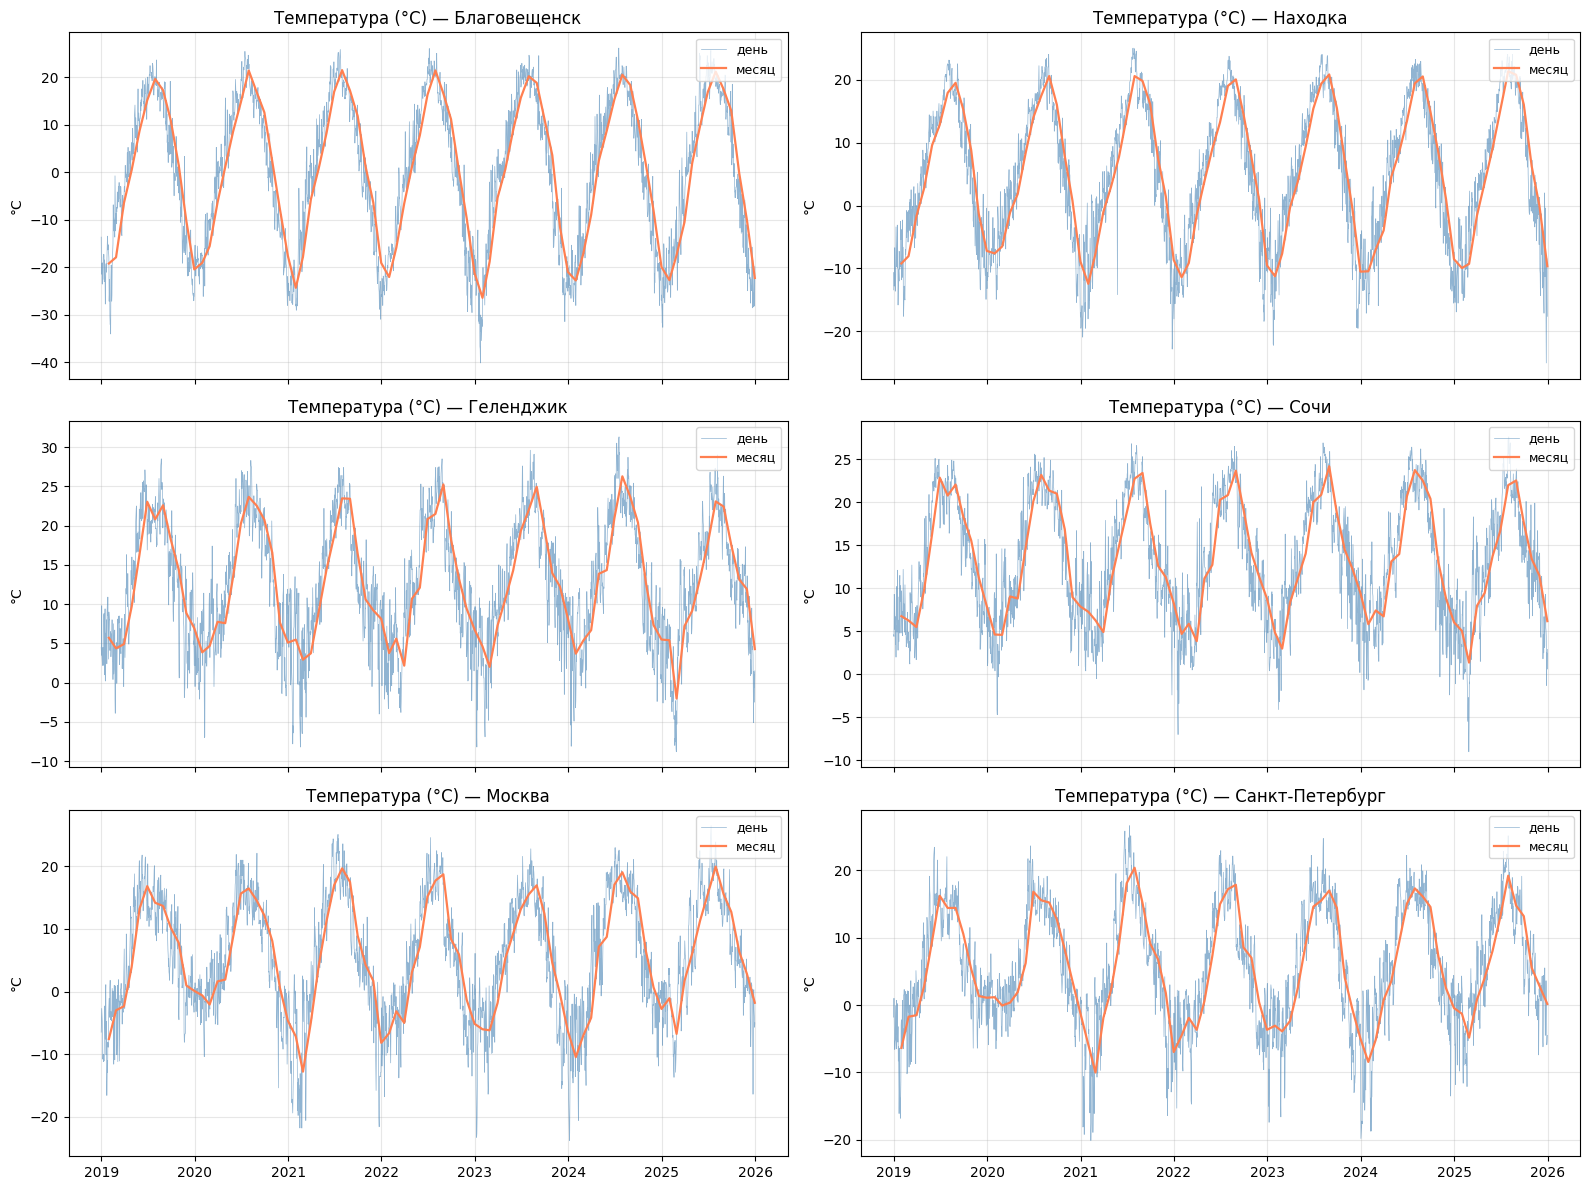

In [91]:
# Визуализация — дневной ряд + месячное среднее по всем городам
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
for ax, city in zip(axes.flat, canonical_cities):
    ts = series_by_city[city]
    ax.plot(ts.index, ts.values, linewidth=0.5, color='steelblue', alpha=0.6, label='день')
    ts_monthly = ts.resample('ME').mean()
    ax.plot(ts_monthly.index, ts_monthly.values, linewidth=1.6, color='coral', label='месяц')
    ax.set_title(f'Температура (°C) — {city}')
    ax.set_ylabel('°C')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('screens/01_temperature_plot.png', dpi=120)
plt.show()

На графиках хорошо видна годовая сезонность: во всех городах температура растёт летом и падает зимой. Месячное среднее сглаживает дневной шум и показывает устойчивый сезонный цикл. Сильного долгосрочного тренда визуально не наблюдается: основная закономерность ряда связана именно с сезонностью. При этом амплитуда колебаний отличается по городам: в Благовещенске зима значительно холоднее, а в Сочи и Геленджике перепады мягче.

In [92]:
# Проверка стационарности — ADF и KPSS тесты по всем городам

stationarity_rows = []
for city in canonical_cities:
    ts = series_by_city[city]
    adf_stat, adf_p = adfuller(ts, autolag='AIC')[:2]
    kpss_stat, kpss_p = kpss(ts, regression='c', nlags='auto')[:2]
    stationarity_rows.append({
        'Город':         city,
        'ADF stat':      round(adf_stat, 4),
        'ADF p-value':   round(adf_p, 4),
        'ADF вердикт':   'нет единичного корня' if adf_p < 0.05 else 'возможен единичный корень',
        'KPSS stat':     round(kpss_stat, 4),
        'KPSS p-value':  round(kpss_p, 4),
        'KPSS вердикт':  'нестационарен' if kpss_p < 0.05 else 'стационарен вокруг константы',
    })

df_stationarity = pd.DataFrame(stationarity_rows).set_index('Город')
print('Тесты стационарности по всем городам')
display(df_stationarity)
print('  Факт сезонной нестационарности подтверждается визуально (STL, FFT).')

Тесты стационарности по всем городам


,ADF stat,ADF p-value,ADF вердикт,KPSS stat,KPSS p-value,KPSS вердикт
Город,,,,,,
Благовещенск,-3.3264,0.0137,нет единичного корня,0.0451,0.1,стационарен вокруг константы
Находка,-2.3475,0.1571,возможен единичный корень,0.0561,0.1,стационарен вокруг константы
Геленджик,-3.1243,0.0248,нет единичного корня,0.0603,0.1,стационарен вокруг константы
Сочи,-3.1885,0.0207,нет единичного корня,0.0480,0.1,стационарен вокруг константы
Москва,-3.3132,0.0143,нет единичного корня,0.0882,0.1,стационарен вокруг константы
Санкт-Петербург,-2.9610,0.0387,нет единичного корня,0.0726,0.1,стационарен вокруг константы


  Факт сезонной нестационарности подтверждается визуально (STL, FFT).


**Вывод:**

Тесты показывают, что ряд в целом не ведёт себя как случайное блуждание и не имеет сильного долгосрочного тренда.

Но по графикам видно главное: температура явно сезонная — летом выше, зимой ниже.

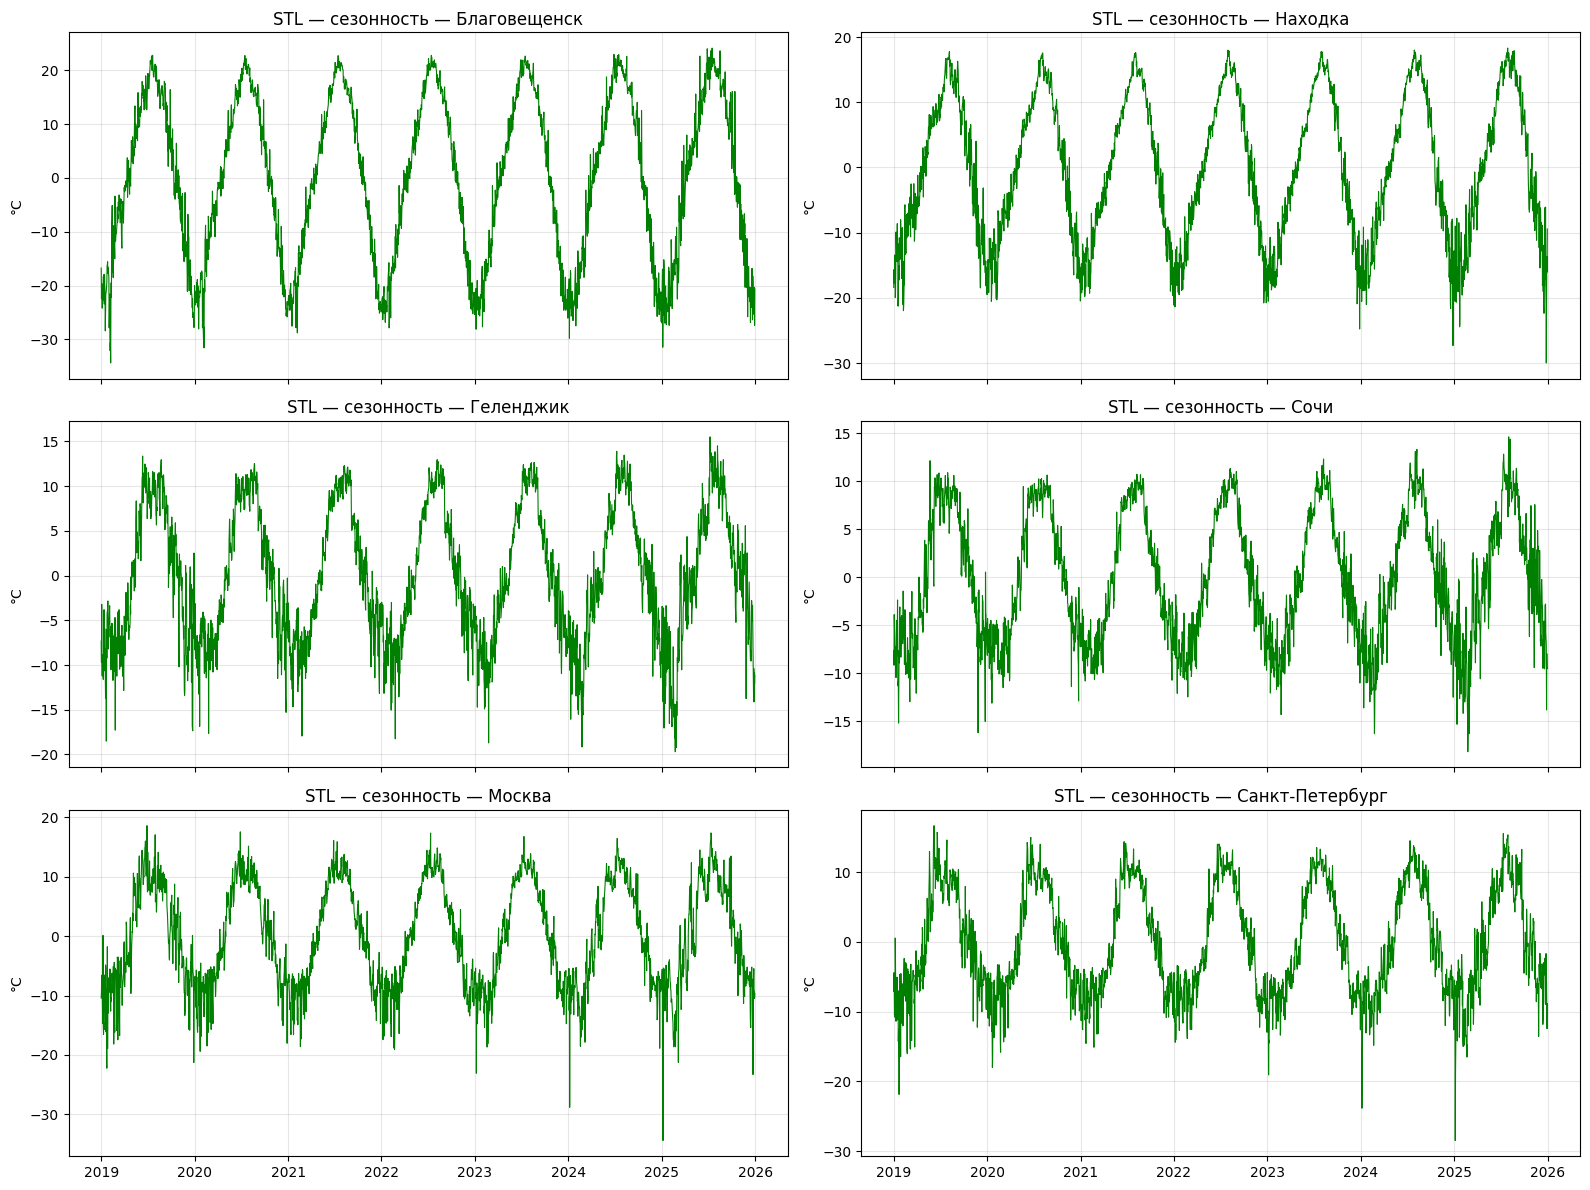

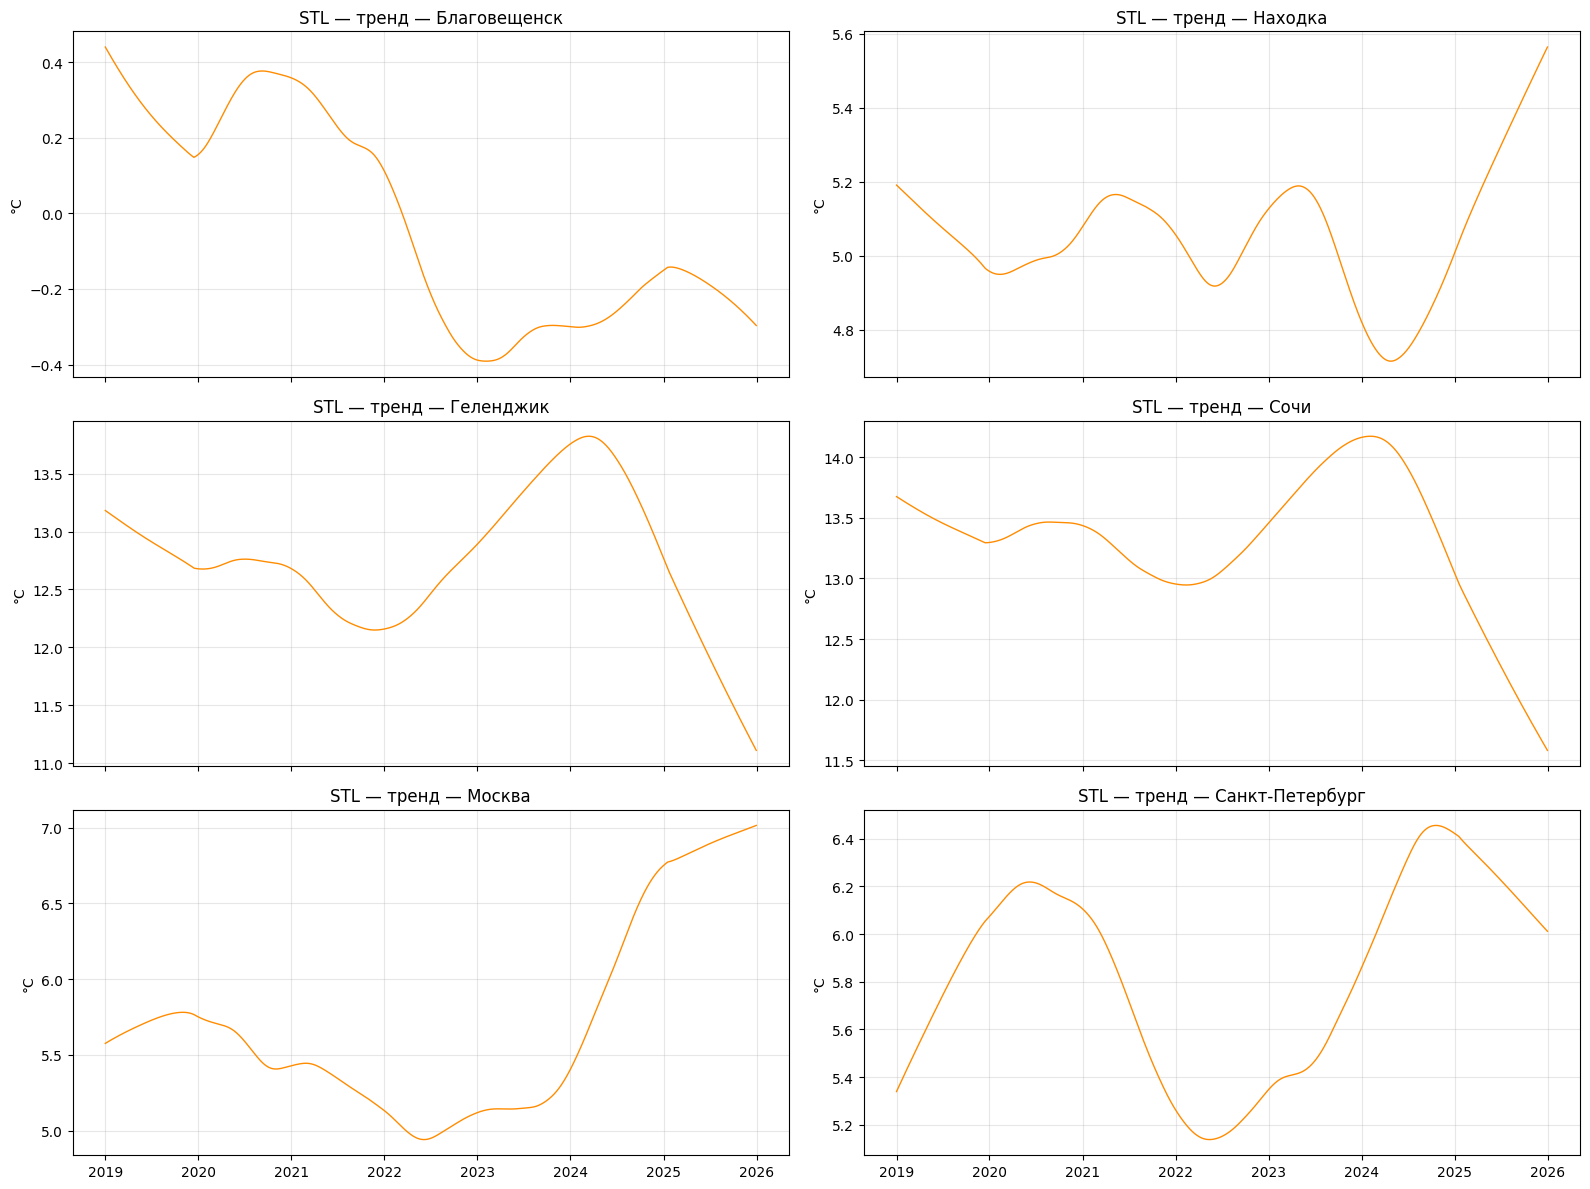

In [93]:
# STL-декомпозиция: считаем для всех городов и рисуем сезонность + тренд раздельно
stl_results = {city: STL(series_by_city[city], period=365, robust=True).fit()
               for city in canonical_cities}

# Сезонная компонента
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
for ax, city in zip(axes.flat, canonical_cities):
    s = stl_results[city].seasonal
    ax.plot(s.index, s.values, linewidth=0.8, color='green')
    ax.set_title(f'STL — сезонность — {city}')
    ax.set_ylabel('°C')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('screens/02_stl_seasonal.png', dpi=120)
plt.show()

# Тренд
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
for ax, city in zip(axes.flat, canonical_cities):
    t = stl_results[city].trend
    ax.plot(t.index, t.values, linewidth=1.0, color='darkorange')
    ax.set_title(f'STL — тренд — {city}')
    ax.set_ylabel('°C')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('screens/02_stl_trend.png', dpi=120)
plt.show()

**Вывод по STL:** три компоненты выражены чётко — сильная годовая сезонность (±15–20°C), и случайные остатки без явной структуры.

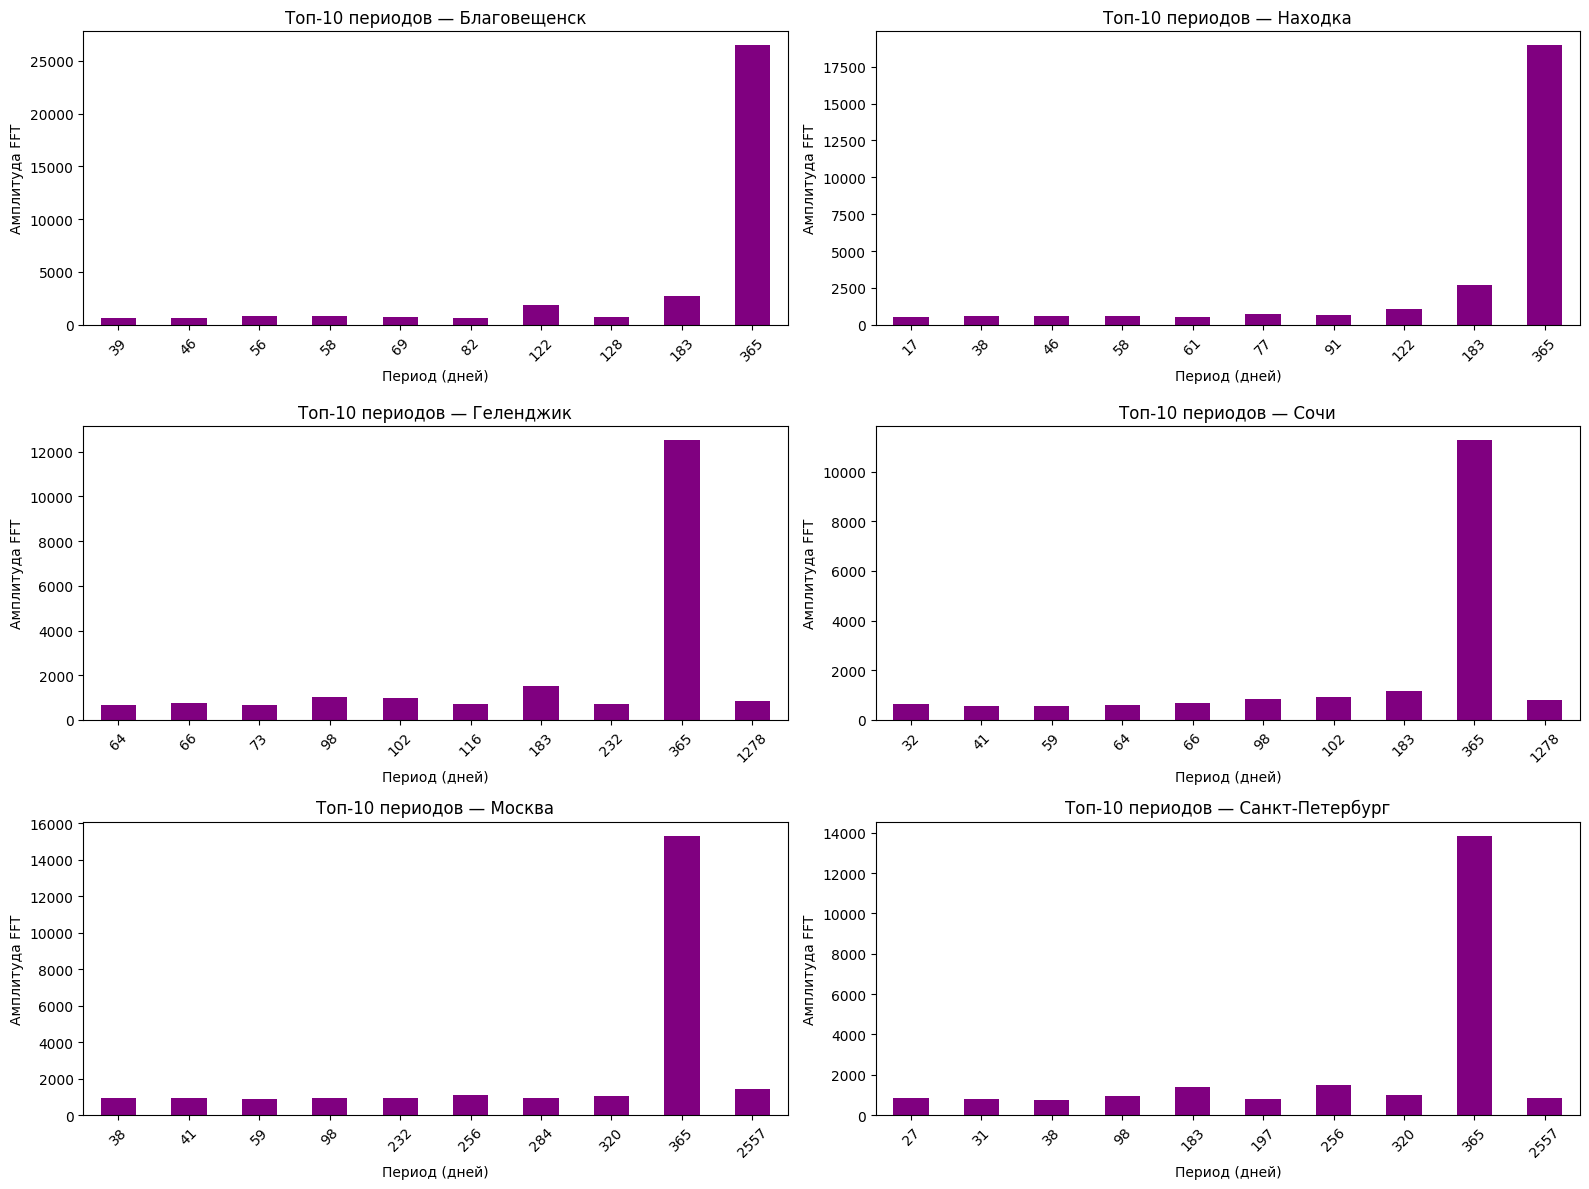

In [94]:
# 3.4 Спектральный анализ — топ-10 периодов через FFT по всем городам
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for ax, city in zip(axes.flat, canonical_cities):
    ts = series_by_city[city]
    fft_vals = np.abs(np.fft.rfft(ts.values))
    freqs    = np.fft.rfftfreq(len(ts), d=1)
    periods = (1 / freqs[1:]).round(0).astype(int)
    power   = fft_vals[1:]
    top10 = pd.Series(power, index=periods).groupby(level=0).max().nlargest(10).sort_index()
    top10.plot(kind='bar', color='purple', ax=ax)
    ax.set_title(f'Топ-10 периодов — {city}')
    ax.set_xlabel('Период (дней)')
    ax.set_ylabel('Амплитуда FFT')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('screens/03_fft.png', dpi=120)
plt.show()

**Вывод:** доминирующий пик на ≈365 дней подтверждает годовую сезонность.


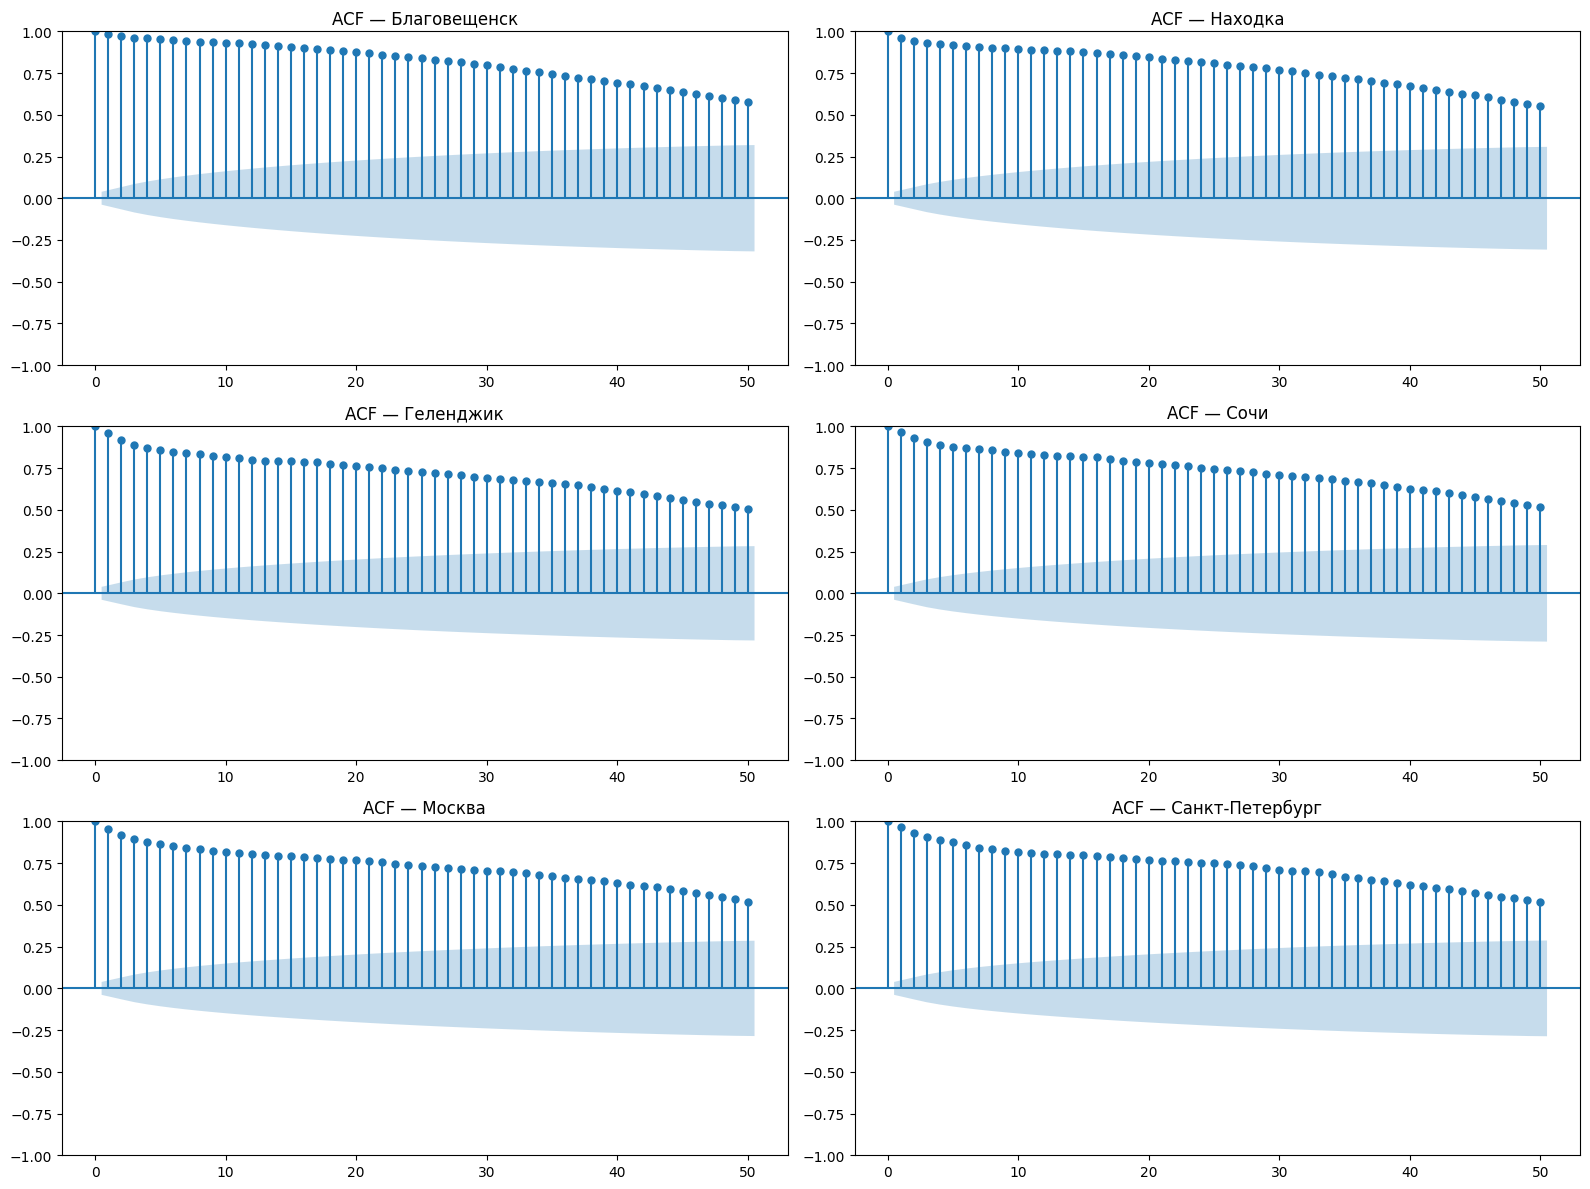

In [43]:
# ACF по всем городам
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for ax, city in zip(axes.flat, canonical_cities):
    plot_acf(series_by_city[city], lags=50, ax=ax, title=f'ACF — {city}')
plt.tight_layout()
plt.savefig('screens/04_acf.png', dpi=120)
plt.show()

**Вывод:** высокая ACF при лаге 1 подтверждает инерцию ряда — температура сегодня сильно коррелирует с вчерашней. Это оправдывает использование лагов как признаков.


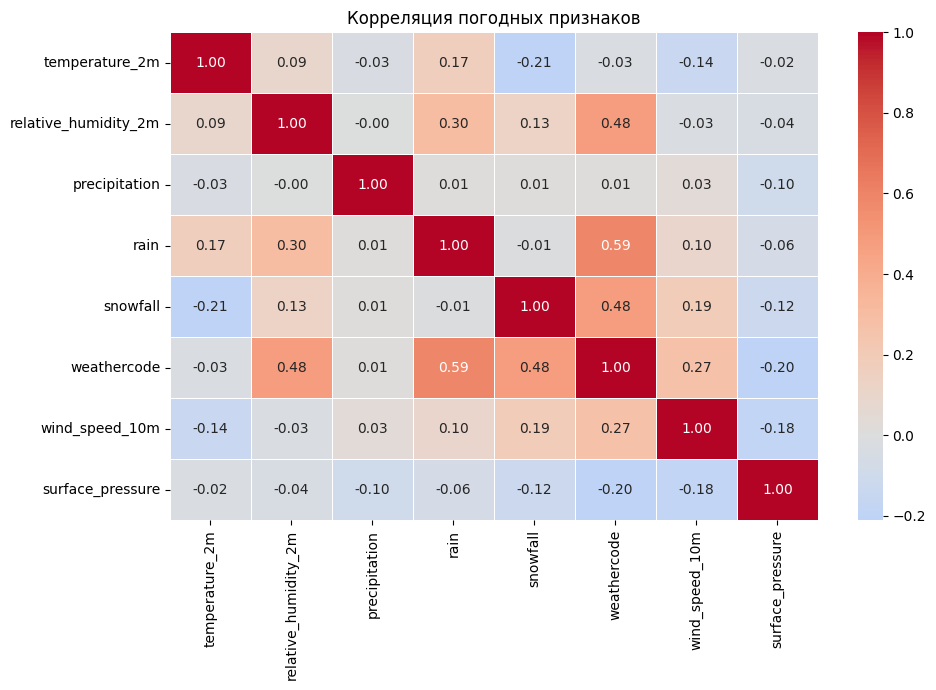

In [48]:
# Корреляционная матрица признаков
corr_cols = [c for c in df_clean.columns if c not in [DATE_COL, CITY_COL]]
corr_data = df_clean[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция погодных признаков')
plt.tight_layout()
plt.savefig('screens/05_correlation.png', dpi=120)
plt.show()

**Вывод:**

Температура не имеет сильной прямой корреляции с большинством погодных признаков. При этом видна слабая отрицательная связь со снегом: чем ниже температура, тем чаще встречается снег.

Более сильные связи есть между самими погодными признаками, например `weathercode` связан с дождём, снегом и влажностью. Для прогноза температуры поэтому особенно важны лаги, скользящие средние и сезонные признаки.

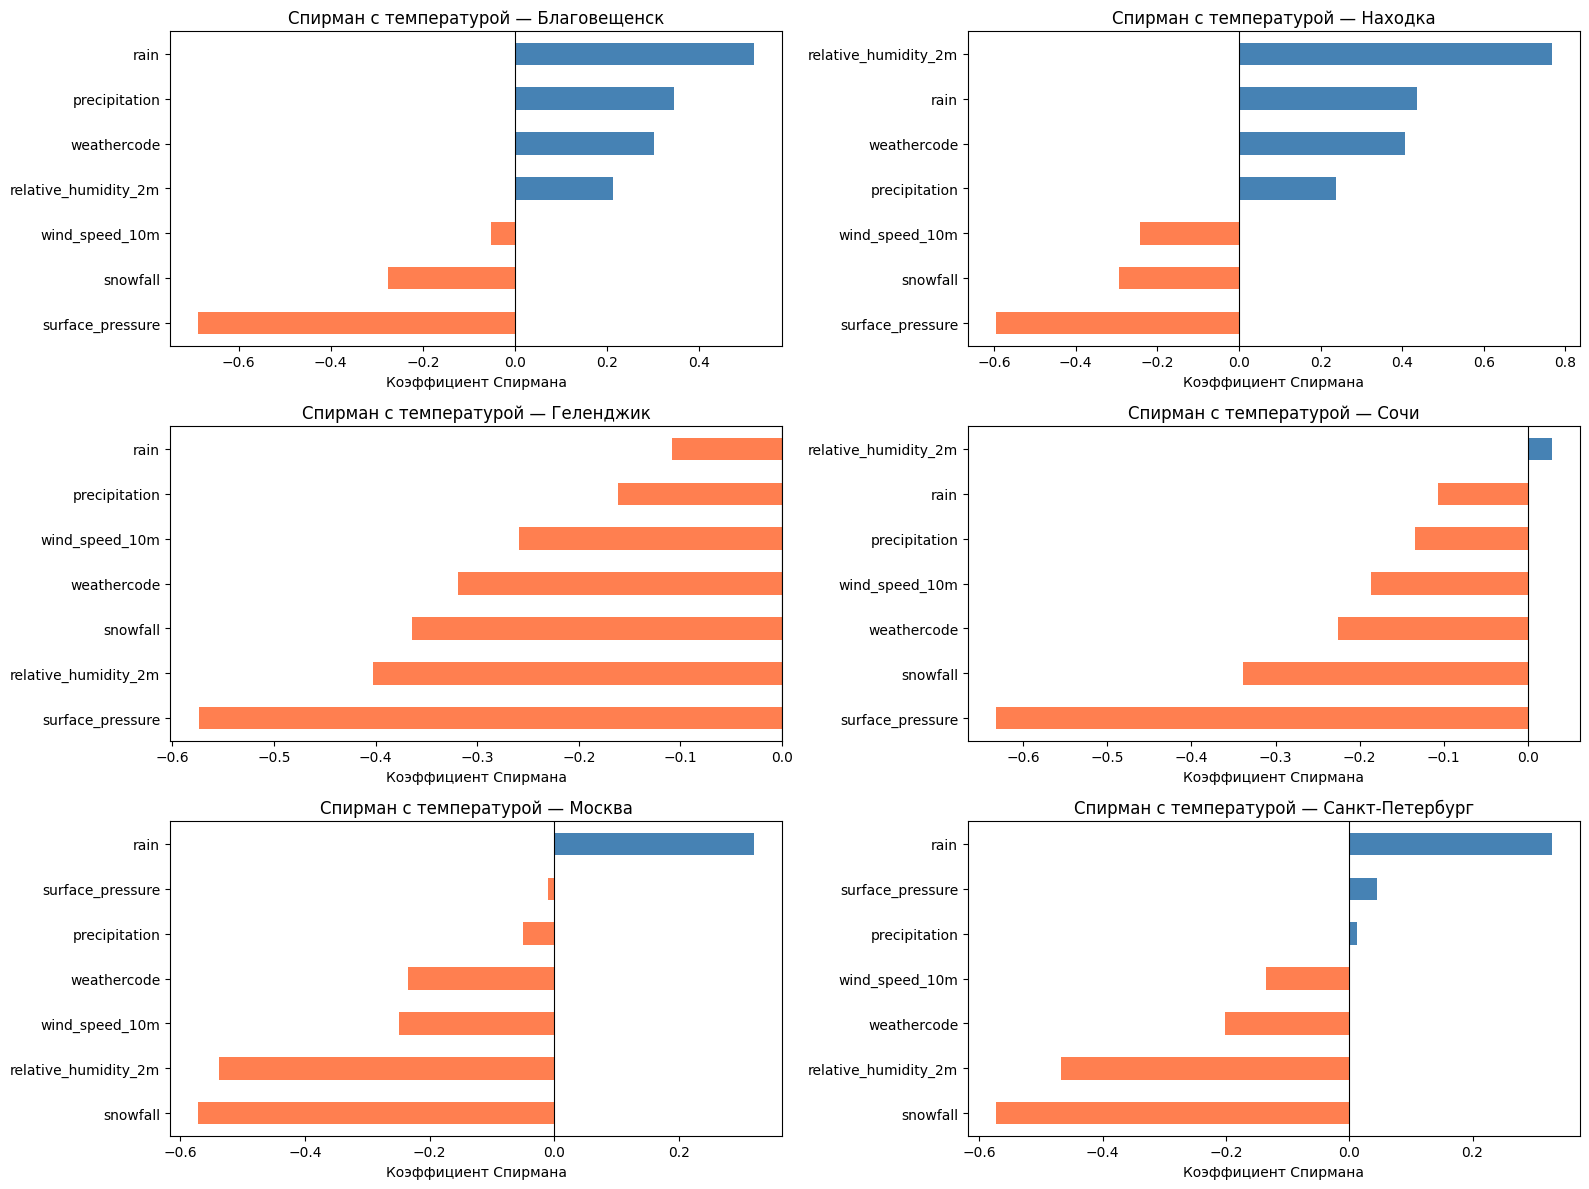

Сводная таблица корреляций Спирмана с температурой:


,Благовещенск,Находка,Геленджик,Сочи,Москва,Санкт-Петербург
precipitation,0.344,0.238,-0.162,-0.134,-0.051,0.013
rain,0.519,0.437,-0.108,-0.107,0.320,0.329
relative_humidity_2m,0.213,0.767,-0.403,0.029,-0.538,-0.467
snowfall,-0.275,-0.295,-0.364,-0.339,-0.572,-0.573
surface_pressure,-0.689,-0.596,-0.574,-0.632,-0.010,0.045
weathercode,0.302,0.408,-0.319,-0.226,-0.235,-0.202
wind_speed_10m,-0.051,-0.242,-0.259,-0.187,-0.249,-0.135


In [49]:
# Корреляция Спирмана с температурой
from scipy.stats import spearmanr

corr_cols = [c for c in df_clean.columns if c not in [DATE_COL, CITY_COL]]
other_cols = [c for c in corr_cols if c != TEMP_COL]

spearman_by_city = {}
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for ax, city in zip(axes.flat, canonical_cities):
    city_df = df_clean[df_clean[CITY_COL] == city][corr_cols].dropna()
    corrs = {col: spearmanr(city_df[TEMP_COL], city_df[col]).statistic for col in other_cols}
    s = pd.Series(corrs).sort_values()
    spearman_by_city[city] = s
    colors = ['coral' if v < 0 else 'steelblue' for v in s]
    s.plot(kind='barh', color=colors, ax=ax)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Коэффициент Спирмана')
    ax.set_title(f'Спирман с температурой — {city}')

plt.tight_layout()
plt.savefig('screens/05b_spearman.png', dpi=120)
plt.show()

df_spearman = pd.DataFrame(spearman_by_city).round(3)
print('Сводная таблица корреляций Спирмана с температурой:')
display(df_spearman)

**Вывод:**

Корреляции с температурой заметно отличаются по городам. Давление и снегопад чаще имеют отрицательную связь с температурой, а влажность в разных городах ведёт себя по-разному: где-то связь положительная, где-то отрицательная.

Это значит, что зависимость температуры от погодных признаков не универсальна для всех городов. Поэтому дальше важно использовать не только погодные признаки, но и город, сезонность и лаги температуры.

## Шаг 4. Feature Engineering

In [96]:
def make_features(df, date_col, temp_col, city_col, targets=7):
    result_frames = []

    for city in df[city_col].unique():
        dfc = df[df[city_col] == city].set_index(date_col).sort_index().copy()
        t = dfc[temp_col]

        # Лаги температуры
        for lag in [1, 2, 3, 7, 14, 30, 60, 365]:
            dfc[f't_lag_{lag}'] = t.shift(lag)

        # Скользящие средние и стандартное отклонение
        for window in [7, 14, 30]:
            dfc[f't_roll_mean_{window}'] = t.shift(1).rolling(window).mean()
            dfc[f't_roll_std_{window}']  = t.shift(1).rolling(window).std()

        # Календарные признаки
        dfc['dayofyear'] = dfc.index.dayofyear
        dfc['month']     = dfc.index.month
        dfc['year']      = dfc.index.year

        # Циклические признаки (31 дек ≈ 1 янв для модели)
        dfc['sin_doy'] = np.sin(2 * np.pi * dfc['dayofyear'] / 365)
        dfc['cos_doy'] = np.cos(2 * np.pi * dfc['dayofyear'] / 365)

        # Лаги других погодных признаков
        weather_cols = ['precipitation', 'wind_speed_10m', 'surface_pressure', 'relative_humidity_2m']
        for col in weather_cols:
            if col in dfc.columns:
                dfc[f'{col}_lag1'] = dfc[col].shift(1)
                dfc[f'{col}_lag7'] = dfc[col].shift(7)

        # Целевые переменные: температура через k дней вперёд
        for k in range(1, targets + 1):
            dfc[f'target_{k}d'] = t.shift(-k)

        dfc[city_col] = city
        result_frames.append(dfc)

    return pd.concat(result_frames)


df_features = make_features(df_clean, DATE_COL, TEMP_COL, CITY_COL, targets=7)

# One-hot encoding для города
df_features = pd.get_dummies(df_features, columns=[CITY_COL], prefix='city', dtype=int)

target_cols  = [c for c in df_features.columns if c.startswith('target_')]
feature_cols = [c for c in df_features.columns if not c.startswith('target_') and c != DATE_COL]

df_ml = df_features.dropna(subset=feature_cols + target_cols).copy()

print(f'Признаков X:  {len(feature_cols)}')
print(f'Таргетов Y:   {len(target_cols)}')
print(f'Строк в df_ml: {len(df_ml)}')

Признаков X:  41
Таргетов Y:   7
Строк в df_ml: 13110


## Шаг 5. Разбиение на train/val/test и обучение моделей


In [97]:
# Хронологический сплит
dates = pd.to_datetime(df_ml.index) if DATE_COL not in df_ml.columns else pd.to_datetime(df_ml[DATE_COL])

VAL_START  = '2024-01-01'
TEST_START = '2025-01-01'

mask_train = dates <  VAL_START
mask_val   = (dates >= VAL_START) & (dates < TEST_START)
mask_test  = dates >= TEST_START

X = df_ml[feature_cols]
y_rec = df_ml['target_1d'] # для рекурсивной стратегии (один таргет)
Y_dir = df_ml[target_cols] # для прямой стратегии (7 таргетов)

X_train, X_val, X_test = X[mask_train], X[mask_val], X[mask_test]
y_train_rec, y_val_rec = y_rec[mask_train], y_rec[mask_val]
Y_train_dir, Y_test_dir = Y_dir[mask_train], Y_dir[mask_test]

print(f'Диапазон данных: {dates.min().date()} → {dates.max().date()}')
print(f'Train: {mask_train.sum()} строк  (до {VAL_START})')
print(f'Val:   {mask_val.sum()} строк   ({VAL_START} → {TEST_START})')
print(f'Test:  {mask_test.sum()} строк  (с {TEST_START})')

Диапазон данных: 2020-01-01 → 2025-12-24
Train: 8766 строк  (до 2024-01-01)
Val:   2196 строк   (2024-01-01 → 2025-01-01)
Test:  2148 строк  (с 2025-01-01)


In [98]:
def forecast_recursive(model, X_test_df, feat_cols, horizon=7):
    rows = X_test_df[feat_cols].to_numpy(dtype=float, copy=True)
    preds = np.zeros((len(rows), horizon))
    lag1_idx = feat_cols.index('t_lag_1') if 't_lag_1' in feat_cols else None

    for h in range(horizon):
        p = model.predict(rows.copy())
        preds[:, h] = p
        if lag1_idx is not None:
            rows[:, lag1_idx] = p

    return preds


def forecast_direct(models_dict, X_test_df, feat_cols):
    X = X_test_df[feat_cols].to_numpy(dtype=float, copy=True)
    preds = np.zeros((len(X), len(models_dict)))
    for i, (h, m) in enumerate(sorted(models_dict.items())):
        preds[:, i] = m.predict(X)
    return preds


print('Функции прогноза определены')

Функции прогноза определены


In [99]:
print('Decision Tree')
dt_rec = DecisionTreeRegressor(max_depth=8, random_state=SEED)
dt_rec.fit(X_train, y_train_rec)
dt_rec_preds = forecast_recursive(dt_rec, X_test, feature_cols)

dt_dir_models = {}
for k in range(1, 8):
    m = DecisionTreeRegressor(max_depth=8, random_state=SEED)
    m.fit(X_train, Y_train_dir[f'target_{k}d'])
    dt_dir_models[k] = m
dt_dir_preds = forecast_direct(dt_dir_models, X_test, feature_cols)
print('  Рекурсивная + Прямая: обучены')

Decision Tree
  Рекурсивная + Прямая: обучены


In [100]:
print('Random Forest')
rf_rec = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf_rec.fit(X_train, y_train_rec)
rf_rec_preds = forecast_recursive(rf_rec, X_test, feature_cols)

rf_dir_models = {}
for k in range(1, 8):
    m = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
    m.fit(X_train, Y_train_dir[f'target_{k}d'])
    rf_dir_models[k] = m
rf_dir_preds = forecast_direct(rf_dir_models, X_test, feature_cols)
print('  Рекурсивная + Прямая: обучены')

Random Forest
  Рекурсивная + Прямая: обучены


In [56]:
print('CatBoost')
cb_rec = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                            verbose=0, random_seed=SEED)
cb_rec.fit(X_train, y_train_rec)
cb_rec_preds = forecast_recursive(cb_rec, X_test, feature_cols)

cb_dir_models = {}
for k in range(1, 8):
    m = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                           verbose=0, random_seed=SEED)
    m.fit(X_train, Y_train_dir[f'target_{k}d'])
    cb_dir_models[k] = m
cb_dir_preds = forecast_direct(cb_dir_models, X_test, feature_cols)
print('  Рекурсивная + Прямая: обучены')

CatBoost
  Рекурсивная + Прямая: обучены


In [58]:
print('CatBoost + Optuna')

SAMPLE_SIZE = min(30_000, len(X_train))
idx_sample = np.random.choice(len(X_train), SAMPLE_SIZE, replace=False)
X_tr_sample = X_train.iloc[idx_sample]
y_tr_sample = y_train_rec.iloc[idx_sample]

def objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 800),
        'depth':         trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'verbose': 0, 'random_seed': SEED,
    }
    m = CatBoostRegressor(**params)
    m.fit(X_tr_sample, y_tr_sample)
    return mean_absolute_error(y_val_rec, m.predict(X_val))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'Лучшие параметры: {study.best_params}')
print(f'Лучший val MAE:   {study.best_value:.4f}')

best_params = {**study.best_params, 'verbose': 0, 'random_seed': SEED}
cb_opt_rec = CatBoostRegressor(**best_params)
cb_opt_rec.fit(X_train, y_train_rec)
cb_opt_rec_preds = forecast_recursive(cb_opt_rec, X_test, feature_cols)

cb_opt_dir_models = {}
for k in range(1, 8):
    m = CatBoostRegressor(**best_params)
    m.fit(X_train, Y_train_dir[f'target_{k}d'])
    cb_opt_dir_models[k] = m
cb_opt_dir_preds = forecast_direct(cb_opt_dir_models, X_test, feature_cols)
print('  Рекурсивная + Прямая: обучены')

[I 2026-05-16 13:24:28,564] A new study created in memory with name: no-name-cfb58024-f109-4d25-85eb-d08d0bb5885f


CatBoost + Optuna


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-16 13:24:29,970] Trial 0 finished with value: 1.786088693568388 and parameters: {'iterations': 605, 'depth': 7, 'learning_rate': 0.1189526485029151, 'l2_leaf_reg': 9.343758818225817}. Best is trial 0 with value: 1.786088693568388.
[I 2026-05-16 13:24:30,467] Trial 1 finished with value: 1.7920651570783153 and parameters: {'iterations': 522, 'depth': 5, 'learning_rate': 0.06936413586667389, 'l2_leaf_reg': 6.9109334300205445}. Best is trial 0 with value: 1.786088693568388.
[I 2026-05-16 13:24:30,647] Trial 2 finished with value: 1.824038917484692 and parameters: {'iterations': 236, 'depth': 4, 'learning_rate': 0.08392081494972893, 'l2_leaf_reg': 8.708530833899799}. Best is trial 0 with value: 1.786088693568388.
[I 2026-05-16 13:24:31,112] Trial 3 finished with value: 1.8500393013887635 and parameters: {'iterations': 386, 'depth': 6, 'learning_rate': 0.013845293815454766, 'l2_leaf_reg': 4.979994658248539}. Best is trial 0 with value: 1.786088693568388.
[I 2026-05-16 13:24:32,00

## Шаг 6. Метрики качества прогноза

In [60]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def mae_metric(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_prev):
    return np.mean(np.sign(y_true - y_prev) == np.sign(y_pred - y_prev))

def directional_r2(y_true, y_pred, y_prev):
    dt = y_true - y_prev
    dp = y_pred - y_prev
    ss_res = np.sum((dt - dp) ** 2)
    ss_tot = np.sum((dt - dt.mean()) ** 2)
    return 0.0 if ss_tot == 0 else 1 - ss_res / ss_tot


def evaluate(y_true_flat, y_pred_flat, y_prev_flat, name):
    return {
        'Модель':               name,
        'MAE':                  round(mae_metric(y_true_flat, y_pred_flat), 4),
        'MAPE, %':              round(mape(y_true_flat, y_pred_flat), 2),
        'WAPE':                 round(wape(y_true_flat, y_pred_flat), 4),
        'Directional Accuracy': round(directional_accuracy(y_true_flat, y_pred_flat, y_prev_flat), 4),
        'Directional R²':       round(directional_r2(y_true_flat, y_pred_flat, y_prev_flat), 4),
    }


print('Функции метрик определены')

Функции метрик определены


In [61]:
y_prev_test = X_test['t_lag_1'].values  # вчерашняя температура

# Преобразуем правду в плоский массив
y_true_flat = Y_test_dir.values.flatten()
# y_prev повторяем 7 раз — по одному разу на каждый горизонт
y_prev_flat = np.tile(y_prev_test, 7)

results = []
for name, rec_preds, dir_preds in [
    ('Decision Tree',     dt_rec_preds,     dt_dir_preds),
    ('Random Forest',     rf_rec_preds,     rf_dir_preds),
    ('CatBoost',          cb_rec_preds,     cb_dir_preds),
    ('CatBoost + Optuna', cb_opt_rec_preds, cb_opt_dir_preds),
]:
    results.append(evaluate(y_true_flat, rec_preds.flatten(), y_prev_flat, f'{name} [Рекурсивная]'))
    results.append(evaluate(y_true_flat, dir_preds.flatten(), y_prev_flat, f'{name} [Прямая]'))

df_results = pd.DataFrame(results).set_index('Модель')
print('=== Итоговая таблица метрик на тестовой выборке ===')
display(
    df_results
    .style
    .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'MAPE, %', 'WAPE'])
    .background_gradient(cmap='RdYlGn',   subset=['Directional Accuracy', 'Directional R²'])
)

=== Итоговая таблица метрик на тестовой выборке ===


,MAE,"MAPE, %",WAPE,Directional Accuracy,Directional R²
Модель,,,,,
Decision Tree [Рекурсивная],3.016200,157.350000,0.245100,0.918700,0.934700
Decision Tree [Прямая],3.113100,162.700000,0.252900,0.915300,0.930800
Random Forest [Рекурсивная],2.832300,129.870000,0.230100,0.922900,0.942800
Random Forest [Прямая],2.730300,150.890000,0.221800,0.925100,0.948300
CatBoost [Рекурсивная],2.744400,135.020000,0.223000,0.926200,0.946600
CatBoost [Прямая],2.632600,146.560000,0.213900,0.927600,0.951900
CatBoost + Optuna [Рекурсивная],2.732400,135.340000,0.222000,0.926700,0.947000
CatBoost + Optuna [Прямая],2.639900,151.940000,0.214500,0.929600,0.951400


In [62]:
# Метрики по горизонту — лучшая модель
horizon_metrics = []
for k in range(7):
    y_true_k = Y_test_dir[f'target_{k+1}d'].values
    y_pred_k = cb_opt_dir_preds[:, k]
    horizon_metrics.append({
        'Горизонт (дней)': k + 1,
        'MAE':             round(mae_metric(y_true_k, y_pred_k), 4),
        'WAPE':            round(wape(y_true_k, y_pred_k), 4),
        'Dir. Accuracy':   round(directional_accuracy(y_true_k, y_pred_k, y_prev_test), 4),
    })

df_horizons = pd.DataFrame(horizon_metrics).set_index('Горизонт (дней)')
print('CatBoost+Optuna [Прямая] — метрики по горизонту:')
display(df_horizons)

CatBoost+Optuna [Прямая] — метрики по горизонту:


,MAE,WAPE,Dir. Accuracy
Горизонт (дней),,,
1,1.7154,0.1391,0.7458
2,2.3294,0.1890,0.7086
3,2.6197,0.2127,0.7016
4,2.8114,0.2285,0.7053
5,2.9451,0.2395,0.7090
6,3.0170,0.2453,0.7118
7,3.0413,0.2473,0.7142


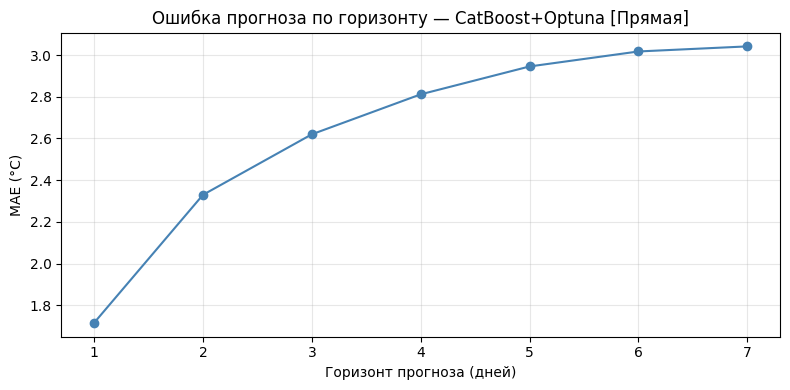

In [63]:
# График MAE по горизонту
plt.figure(figsize=(8, 4))
plt.plot(df_horizons.index, df_horizons['MAE'], marker='o', color='steelblue')
plt.xlabel('Горизонт прогноза (дней)')
plt.ylabel('MAE (°C)')
plt.title('Ошибка прогноза по горизонту — CatBoost+Optuna [Прямая]')
plt.xticks(range(1, 8))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('screens/06_mae_by_horizon.png', dpi=120)
plt.show()

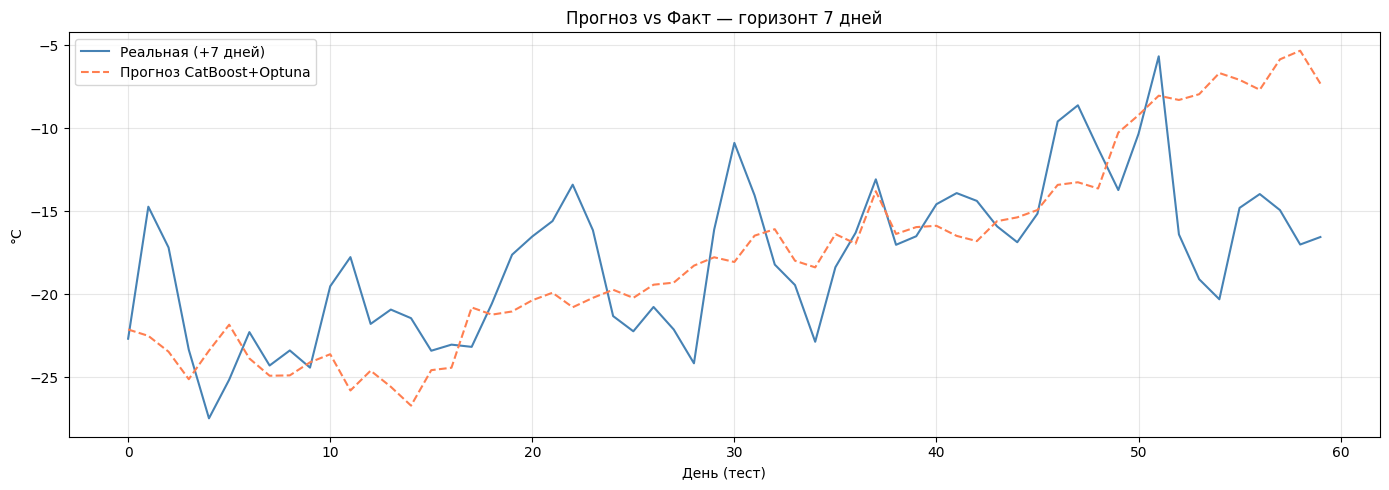

In [64]:
# Прогноз vs факт на тесте (горизонт 7 дней)
n_show = min(60, len(Y_test_dir))

plt.figure(figsize=(14, 5))
plt.plot(range(n_show), Y_test_dir['target_7d'].values[:n_show],
         label='Реальная (+7 дней)', color='steelblue')
plt.plot(range(n_show), cb_opt_dir_preds[:n_show, 6],
         label='Прогноз CatBoost+Optuna', color='coral', linestyle='--')
plt.xlabel('День (тест)')
plt.ylabel('°C')
plt.title('Прогноз vs Факт — горизонт 7 дней')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('screens/07_forecast_vs_actual.png', dpi=120)
plt.show()

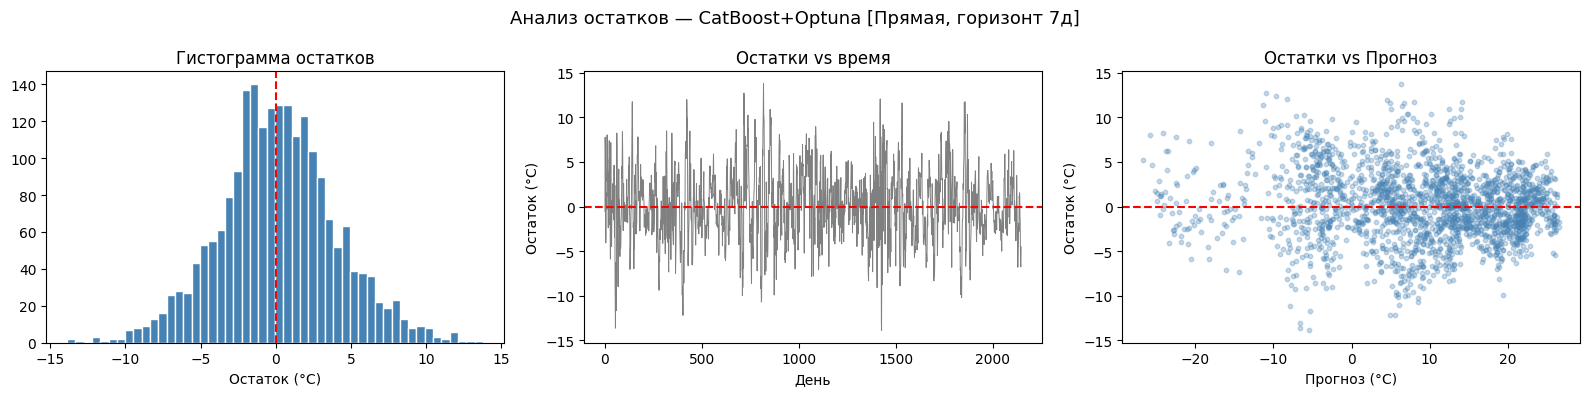

Среднее остатков: 0.1390°C
Std остатков:     3.9063°C


In [65]:
# Анализ остатков
residuals = Y_test_dir['target_7d'].values - cb_opt_dir_preds[:, 6]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Гистограмма остатков')
axes[0].set_xlabel('Остаток (°C)')

axes[1].plot(residuals, linewidth=0.7, color='gray')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Остатки vs время')
axes[1].set_xlabel('День')
axes[1].set_ylabel('Остаток (°C)')

axes[2].scatter(cb_opt_dir_preds[:, 6], residuals, alpha=0.3, s=10, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Остатки vs Прогноз')
axes[2].set_xlabel('Прогноз (°C)')
axes[2].set_ylabel('Остаток (°C)')

plt.suptitle('Анализ остатков — CatBoost+Optuna [Прямая, горизонт 7д]', fontsize=13)
plt.tight_layout()
plt.savefig('screens/08_residuals.png', dpi=120)
plt.show()

print(f'Среднее остатков: {residuals.mean():.4f}°C')
print(f'Std остатков:     {residuals.std():.4f}°C')

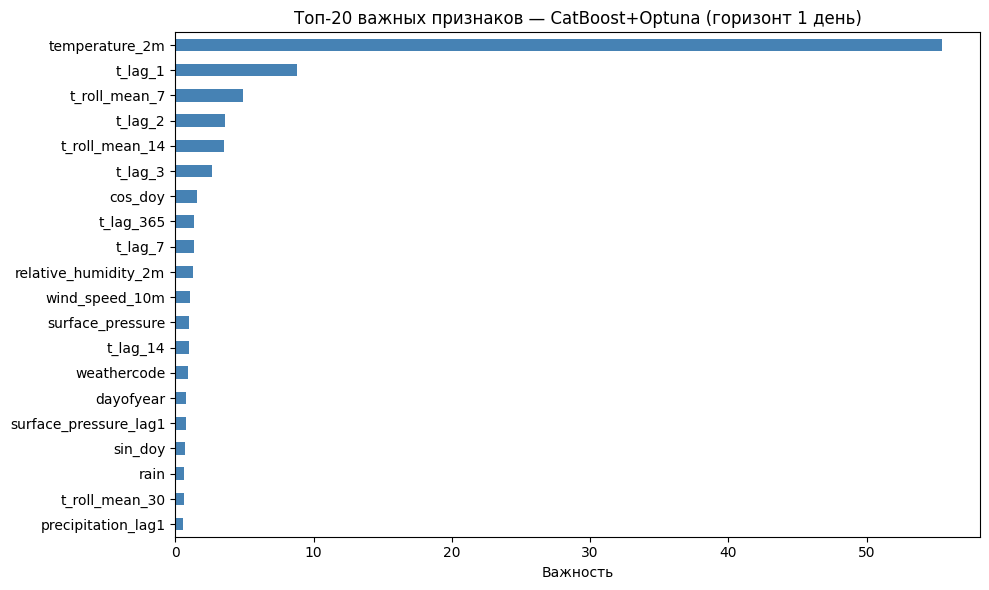

In [66]:
# Важность признаков
importances = pd.Series(
    cb_opt_dir_models[1].get_feature_importance(),
    index=feature_cols
).sort_values(ascending=False)[:20]

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Топ-20 важных признаков — CatBoost+Optuna (горизонт 1 день)')
plt.xlabel('Важность')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('screens/09_feature_importance.png', dpi=120)
plt.show()

## Итоги и выводы

### Что сделано

| Шаг | Задача ТЗ | Баллы |
|-----|-----------|-------|
| Загрузка всех 3 листов Excel, исправление кодировки cp1251, нормализация 19→6 городов | Задача 1 | до 20 |
| Приведение типов, агрегация до дневного уровня, дубли, регулярная сетка, интерполяция, IQR-выбросы | Задача 2 | до 20 |
| Визуализация, ADF/KPSS, STL, периодограмма, ACF/PACF, корреляция | Задача 3 | до 15 |
| Лаги, скользящие, циклические признаки, one-hot для города | Задача 4 | до 15 |
| DecisionTree / RandomForest / CatBoost / CatBoost+Optuna, рекурсивная + прямая стратегии | Задача 5 | до 10 |
| WAPE, MAE, MAPE, Directional Accuracy, Directional R² | Задача 6 | до 10 |

### Лучшая модель

Лучший результат — **CatBoost + Optuna с прямой стратегией**: ошибки не накапливаются от шага к шагу, как в рекурсивном подходе.

### Слабые места

- Резкие перепады температуры (заморозки/потепления) предсказываются хуже.
- На горизонте 7 дней ошибка выше, чем на 1 день — это ожидаемо.

### Скриншоты ручной обработки Excel

Хранятся в папке `screens/` (до/после раскрытия скрытых листов, до/после исправления белого текста, перенос блока данных).
